In [4]:
import kagglehub
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

We import OpenCV for image processing, NumPy for calculations, Matplotlib for visualization, and KaggleHub for dataset download.

In [5]:
path = kagglehub.dataset_download("datasetengineer/crop-health-and-environmental-stress-dataset")

print("Dataset Path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'crop-health-and-environmental-stress-dataset' dataset.
Dataset Path: /kaggle/input/crop-health-and-environmental-stress-dataset
Files: ['agriculture_dataset.csv', '.nfs000000003f94e89d00000247']


The dataset is downloaded from Kaggle and stored in the Colab environment. It contains crop health indicators and environmental stress features.


In [6]:
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (212019, 32)


,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0


The CSV dataset is loaded using Pandas. It contains NDVI and crop-related health indicators.

In [7]:
print(df.columns)

Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='object')


We inspect the dataset columns to identify NDVI and crop health related parameters.

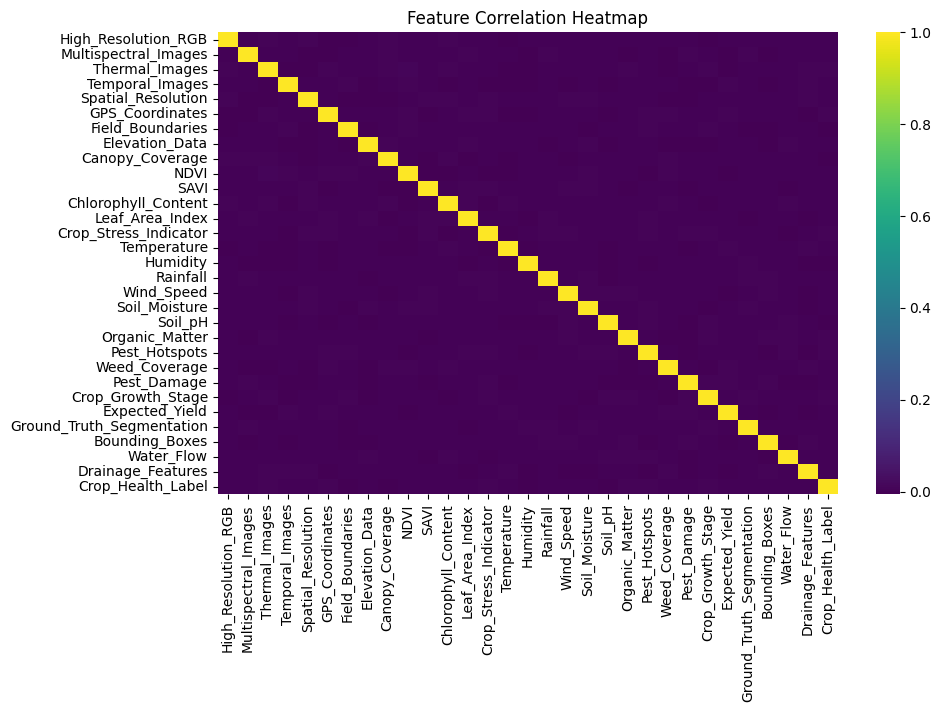

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="viridis")
plt.title("Feature Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical crop health features such as NDVI, temperature, soil moisture, and chlorophyll.

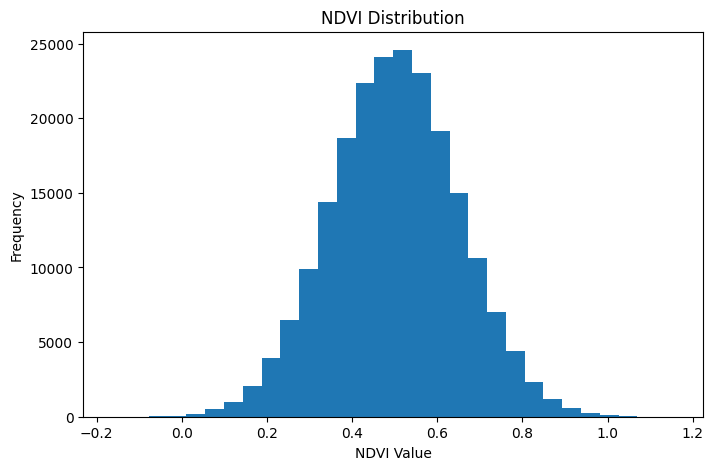

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["NDVI"], bins=30)
plt.title("NDVI Distribution")
plt.xlabel("NDVI Value")
plt.ylabel("Frequency")
plt.show()

NDVI (Normalized Difference Vegetation Index) helps measure crop health.

NDVI=
(NIR+Red/NIR−Red)
	​


Higher NDVI indicates healthier vegetation.

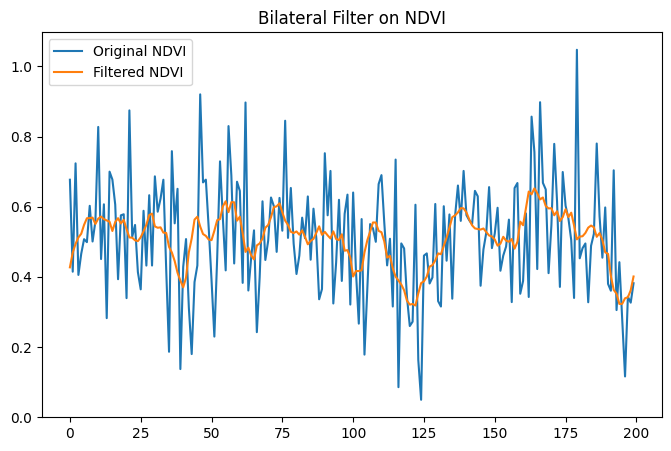

In [9]:
ndvi_array = df["NDVI"].values.astype(np.float32)

# reshape for filter
ndvi_img = ndvi_array.reshape(-1,1)

filtered_ndvi = cv2.bilateralFilter(ndvi_img, 9, 75, 75)

plt.figure(figsize=(8,5))
plt.plot(ndvi_array[:200], label="Original NDVI")
plt.plot(filtered_ndvi[:200], label="Filtered NDVI")
plt.title("Bilateral Filter on NDVI")
plt.legend()
plt.show()

Bilateral filtering reduces noise while preserving important value boundaries, improving crop classification.

In [10]:
df["Health_Status"] = "Moderate"

df.loc[df["NDVI"] < 0.2, "Health_Status"] = "Unhealthy"
df.loc[df["NDVI"] >= 0.5, "Health_Status"] = "Healthy"

df[["NDVI", "Health_Status"]].head(10)

,NDVI,Health_Status
0,0.676945,Healthy
1,0.414781,Moderate
2,0.723610,Healthy
3,0.405611,Moderate
4,0.465992,Moderate
5,0.507520,Healthy
6,0.499019,Moderate
7,0.602585,Healthy
8,0.500893,Healthy
9,0.558419,Healthy


Crop regions are classified based on NDVI values:

*   NDVI < 0.2 → Unhealthy
*   0.2 to 0.5 → Moderate
*  NDVI > 0.5 → Healthy

In [11]:
result = df["Health_Status"].value_counts(normalize=True) * 100
print(result)

Health_Status
Healthy      50.117678
Moderate     47.657050
Unhealthy     2.225272
Name: proportion, dtype: float64


The percentage of healthy, moderate, and unhealthy crop regions is calculated for decision support.

In [15]:
summary = pd.DataFrame({
    "Health Category": result.index,
    "Percentage (%)": result.values
})

summary

,Health Category,Percentage (%)
0,Healthy,50.117678
1,Moderate,47.657050
2,Unhealthy,2.225272


This table summarizes the percentage of healthy, moderate, and unhealthy crop regions for easier interpretation and reporting.

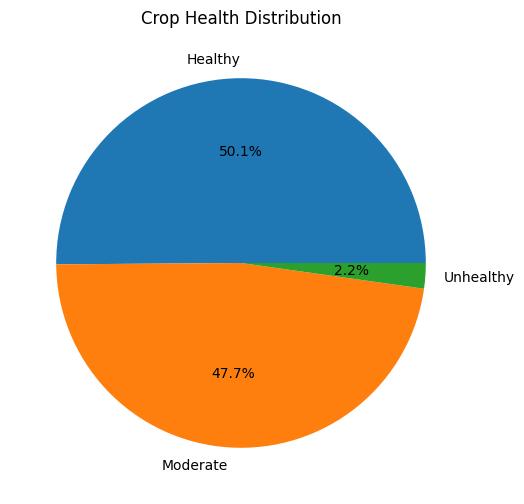

In [12]:
result.plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6),
    title="Crop Health Distribution"
)
plt.ylabel("")
plt.show()

In [13]:
print("Crop Health Monitoring Completed Successfully")
print("System identifies Healthy, Moderate, and Unhealthy crop regions using NDVI analysis.")

Crop Health Monitoring Completed Successfully
System identifies Healthy, Moderate, and Unhealthy crop regions using NDVI analysis.


This project uses NDVI analysis, bilateral filtering, and classification to monitor crop health. It helps farmers detect unhealthy crop regions early and supports precision agriculture.